<a href="https://www.kaggle.com/code/ashutoshsingh00005/notebookb477aed02e?scriptVersionId=298397197" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
file_path = "/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv"
df = pd.read_csv(file_path)
print("Data Shape:", df.shape)
print(df.head())

Data Shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
# Renaming Columns
df.rename(columns={
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'Score'
}, inplace=True)
print(df.head())

   CustomerID  Gender  Age  Income  Score
0           1    Male   19      15     39
1           2    Male   21      15     81
2           3  Female   20      16      6
3           4  Female   23      16     77
4           5  Female   31      17     40


In [5]:
# Dropping irrelevent column
df.drop(columns=['CustomerID'], inplace=True)
print(df.head())

   Gender  Age  Income  Score
0    Male   19      15     39
1    Male   21      15     81
2  Female   20      16      6
3  Female   23      16     77
4  Female   31      17     40


In [6]:
# Handling Missing Values
if df.isnull().sum().sum() > 0:
    print("Missing values found! Filling with Mean...")
    df.fillna(df.mean(numeric_only=True), inplace=True)
else:
    print("No missing values found.")

print(df.head())

No missing values found.
   Gender  Age  Income  Score
0    Male   19      15     39
1    Male   21      15     81
2  Female   20      16      6
3  Female   23      16     77
4  Female   31      17     40


In [7]:
# Encoding Categorical Data (Gender)
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])
print(df.head())

   Gender  Age  Income  Score
0       1   19      15     39
1       1   21      15     81
2       0   20      16      6
3       0   23      16     77
4       0   31      17     40


In [8]:
# Feature Selection
X = df[['Income', 'Score']].values

In [9]:
# Feature Scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(df.head())

   Gender  Age  Income  Score
0       1   19      15     39
1       1   21      15     81
2       0   20      16      6
3       0   23      16     77
4       0   31      17     40


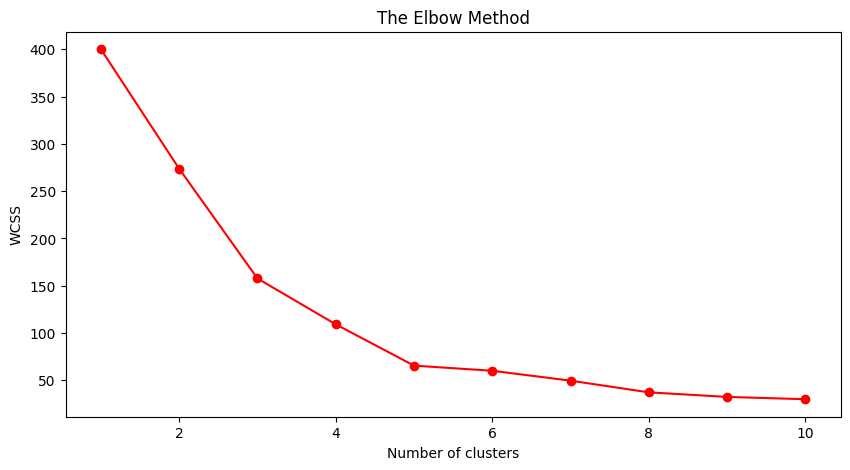

In [10]:
#  Finding optimal k(elbow method)
wcss = [] 
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10,5))
plt.plot(range(1, 11), wcss, marker='o', color='red')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


In [11]:
# Applying k-means algorithm 
optimal_k = 5 
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
y_kmeans = kmeans_model.fit_predict(X_scaled)
df['Cluster_ID'] = y_kmeans
print(df.head())

   Gender  Age  Income  Score  Cluster_ID
0       1   19      15     39           4
1       1   21      15     81           2
2       0   20      16      6           4
3       0   23      16     77           2
4       0   31      17     40           4


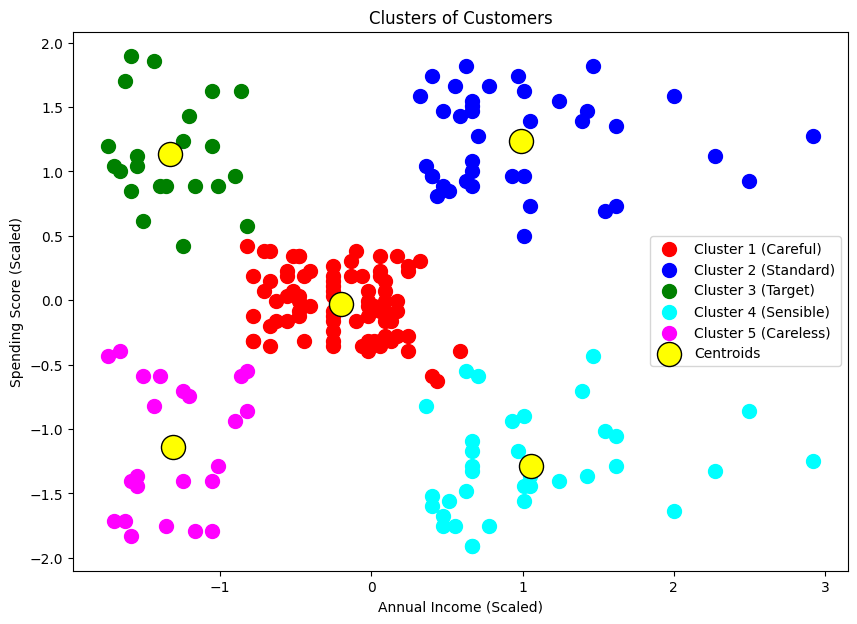

In [12]:
# visualizing the clusters
plt.figure(figsize=(10,7))
plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1 (Careful)')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2 (Standard)')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3 (Target)')
plt.scatter(X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4 (Sensible)')
plt.scatter(X_scaled[y_kmeans == 4, 0], X_scaled[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5 (Careless)')
plt.scatter(kmeans_model.cluster_centers_[:, 0], kmeans_model.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids', edgecolors='black')
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()